<style>
    .title { color: #2c3e50; text-align: center; border-bottom: 1px solid #eee; padding-bottom: 10px; }
    .author { font-style: italic; color: #7f8c8d; text-align: center; margin-top: 5px; }
    .author a { color: #3498db; text-decoration: none; }
</style>

<h1 class="title">Análise Fundamentalista de Ações com Python</h1>
<p class="author">
    <strong>Autor:</strong> Wellington M Santos - Data Scientist <br>
    <strong>LinkedIn:</strong> <a href="https://www.linkedin.com/in/wellington-moreira-santos/" target="_blank">wellington-moreira-santos</a>  
    <strong style='margin-left:1rem'>Email:</strong> <a href="mailto:wsantos08@hotmail.com">wsantos08@hotmail.com</a>
</p>


## Introdução
Neste projeto, utilizo Python para coletar, processar e analisar indicadores
fundamentalistas de ações listadas na B3, a bolsa de valores brasileira. O
objetivo central não é recomendar investimentos, mas demonstrar como estruturar
um pipeline de análise quantitativa a partir de dados financeiros reais,
aplicando critérios objetivos para reduzir um universo amplo de ativos a um
conjunto de candidatos que atendem a determinados padrões de qualidade e valor.

A análise fundamentalista parte do princípio de que o preço de uma ação, no
longo prazo, tende a refletir a qualidade dos fundamentos da empresa que ela
representa. Indicadores como o Preço sobre Lucro (P/L), o Retorno sobre
Patrimônio Líquido (ROE) e o Dividend Yield fornecem uma leitura objetiva sobre
valuation, rentabilidade e geração de caixa. Ao combiná-los de forma estruturada,
consigo construir um funil de seleção que traduz critérios de investimento em
operações sobre dados.

Para a coleta dos dados, utilizo a biblioteca `fundamentus`, que oferece uma
interface Python direta ao site Fundamentus (fundamentus.com.br), uma das
principais fontes públicas de indicadores fundamentalistas do mercado brasileiro.
Todo o processamento é feito com `pandas`, e as visualizações são produzidas com
`matplotlib` e `seaborn`.

Este notebook está organizado nas seguintes etapas:

1. Coleta e inspeção dos dados brutos
2. Limpeza e tratamento de inconsistências
3. Aplicação progressiva do funil de critérios
4. Ranqueamento dos candidatos selecionados
5. Análise setorial dos resultados
6. Conclusão e considerações finais

## 1. Imports e Configurações

Antes de iniciar a análise, importo as bibliotecas necessárias e defino as
configurações visuais que serão utilizadas ao longo do notebook. A biblioteca
`fundamentus` é responsável pela coleta dos dados diretamente do site
Fundamentus, enquanto `pandas` gerencia toda a estrutura tabular. Para as
visualizações, utilizo `matplotlib` e `seaborn`.

In [ ]:
import warnings
import fundamentus
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')


#configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
})

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Coleta e Inspeção dos Dados

Utilizo a função `get_resultado_raw()` da biblioteca `fundamentus` para obter um
snapshot atual de todos os papéis disponíveis na B3 com seus respectivos
indicadores fundamentalistas. O retorno é um DataFrame onde cada linha
representa um papel e cada coluna representa um múltiplo ou indicador.

É importante compreender que os dados coletados representam um momento
específico no tempo. Não se trata de uma série histórica, mas de uma fotografia
do mercado no instante da consulta. Isso tem implicações diretas na
interpretação dos resultados, que discuto ao longo do notebook.

In [6]:
df_raw = fundamentus.get_resultado_raw()

print(f"Dimensões do DataFrame: {df_raw.shape}")
print(f"Total de papéis coletados: {df_raw.shape[0]}")
print(f"\nColunas disponíveis:\n{list(df_raw.columns)}")

Dimensões do DataFrame: (994, 21)
Total de papéis coletados: 994

Colunas disponíveis:
['Cotação', 'P/L', 'P/VP', 'PSR', 'Div.Yield', 'P/Ativo', 'P/Cap.Giro', 'P/EBIT', 'P/Ativ Circ.Liq', 'EV/EBIT', 'EV/EBITDA', 'Mrg Bruta', 'Mrg Ebit', 'Mrg. Líq.', 'Liq. Corr.', 'ROIC', 'ROE', 'Liq.2meses', 'Patrim. Líq', 'Dív.Líq/ Patrim.', 'Cresc. Rec.5a']


### 2.1 Inspeção Inicial

Antes de qualquer processamento, inspeciono a estrutura dos dados para
entender o que foi coletado: tipos de cada coluna, presença de valores nulos
e a distribuição geral dos indicadores. Essa etapa é essencial para tomar
decisões informadas na fase de limpeza.

In [12]:
#visao geral :: primeiros e ultimos 5 registros
df_raw

Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Bruta,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Líq/ Patrim.,Cresc. Rec.5a
papel,,,,,,,,,,,,,,,,,,,,,
AALR3,3.24,-6.13,0.46,0.398,0.0000,0.163,112.89,5.72,-0.44,9.93,...,"26,83%",0.0696,-0.0570,1.01,0.0313,-0.0754,183141.0,1.066930e+09,0.34,0.0234
ABCB3,0.00,0.00,0.00,0.000,0.0000,0.000,0.00,0.00,0.00,0.00,...,"0,00%",0.0000,0.0000,0.00,0.0000,0.1408,0.0,7.147590e+09,0.00,0.0566
ABCB4,24.62,6.37,0.90,0.000,0.0998,0.000,0.00,0.00,0.00,0.00,...,"0,00%",0.0000,0.0000,0.00,0.0000,0.1408,20369800.0,7.147590e+09,0.00,0.0566
ABEV3,16.64,16.84,2.91,2.974,0.0516,1.837,224.37,12.81,-28.81,12.01,...,"51,48%",0.2321,0.1822,1.03,0.2004,0.1728,466210000.0,9.012580e+10,-0.18,0.0458
ABYA3,4.91,-214.80,1.76,2.055,0.0000,0.527,1.98,19.96,-2.75,33.67,...,"32,03%",0.1029,-0.0096,2.09,0.0278,-0.0082,0.0,2.920600e+08,1.21,0.1641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WLMM4,18.21,8.36,0.84,0.226,0.1117,0.421,1.52,5.09,4.79,6.92,...,"13,02%",0.0443,0.0269,1.89,0.1032,0.1000,30292.2,7.931650e+08,0.30,0.1657
WMBY3,25.39,-19.30,2.87,0.836,0.0000,0.182,1.20,8.62,-1.50,25.02,...,"26,91%",0.0970,-0.0705,1.44,0.0239,-0.1486,0.0,2.124390e+08,5.46,-0.1448
WSON33,67.00,8.07,0.98,1.067,0.0000,0.400,13.41,2.42,-0.89,5.08,...,"52,58%",0.4414,0.1358,1.26,0.1836,0.1217,0.0,2.148530e+09,1.08,0.0523


In [ ]:
# tipo de dados
df_raw.dtypes

Multiples
Cotação             float64
P/L                 float64
P/VP                float64
PSR                 float64
Div.Yield           float64
P/Ativo             float64
P/Cap.Giro          float64
P/EBIT              float64
P/Ativ Circ.Liq     float64
EV/EBIT             float64
EV/EBITDA           float64
Mrg Bruta               str
Mrg Ebit            float64
Mrg. Líq.           float64
Liq. Corr.          float64
ROIC                float64
ROE                 float64
Liq.2meses          float64
Patrim. Líq         float64
Dív.Líq/ Patrim.        str
Cresc. Rec.5a       float64
dtype: object

In [15]:
#valores nulos
df_raw.isnull().sum()

Multiples
Cotação             0
P/L                 0
P/VP                0
PSR                 0
Div.Yield           0
P/Ativo             0
P/Cap.Giro          0
P/EBIT              0
P/Ativ Circ.Liq     0
EV/EBIT             0
EV/EBITDA           0
Mrg Bruta           0
Mrg Ebit            0
Mrg. Líq.           0
Liq. Corr.          0
ROIC                0
ROE                 0
Liq.2meses          0
Patrim. Líq         0
Dív.Líq/ Patrim.    0
Cresc. Rec.5a       0
dtype: int64

In [18]:
#estatísticas descritivas
df_raw.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Multiples,,,,,,,,
Cotação,994.0,6.380000e+01,4.901600e+02,0.000000e+00,3.370000e+00,1.108000e+01,2.946000e+01,1.008190e+04
P/L,994.0,-1.210300e+02,4.222430e+03,-1.329930e+05,-1.300000e-01,5.200000e+00,1.320000e+01,2.803570e+03
P/VP,994.0,1.460220e+03,3.177301e+04,-3.591500e+02,9.000000e-02,9.400000e-01,1.960000e+00,7.237080e+05
PSR,994.0,6.505500e+02,2.008114e+04,-9.596100e+02,3.000000e-02,5.400000e-01,1.520000e+00,6.331110e+05
Div.Yield,994.0,4.000000e-02,3.900000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-02,1.203000e+01
P/Ativo,994.0,2.770000e+00,3.375000e+01,0.000000e+00,7.000000e-02,3.500000e-01,7.700000e-01,9.465700e+02
P/Cap.Giro,994.0,-2.582000e+02,8.438140e+03,-2.659860e+05,-1.000000e-02,7.000000e-01,4.060000e+00,3.608020e+03
P/EBIT,994.0,-1.369000e+01,2.829300e+02,-7.214410e+03,0.000000e+00,2.210000e+00,7.500000e+00,6.737500e+02
P/Ativ Circ.Liq,994.0,-2.695100e+02,8.436670e+03,-2.659860e+05,-1.330000e+00,-1.100000e-01,0.000000e+00,2.353100e+02


### 2.2 Distribuições dos Indicadores Brutos

Visualizo as distribuições dos principais indicadores antes de qualquer
filtragem. Esse passo revela algo esperado em dados financeiros reais: a
presença de valores extremos e assimetrias pronunciadas. Empresas com
prejuízo, por exemplo, apresentam P/L negativo, o que distorce a escala
dos gráficos e confirma a necessidade de tratamento antes da análise.

In [22]:
# indicadores = ['P/L', 'P/VP', 'ROE', 'Div.Yield', 'ROIC', 'EV/EBITDA']

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# axes = axes.flatten()

# for i, col in enumerate(indicadores):
#     dados = df_raw[col].replace([float('inf'), float('-inf')], pd.NA).dropna()
#     axes[i].hist(dados, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
#     axes[i].set_title(col)
#     axes[i].set_xlabel('Valor')
#     axes[i].set_ylabel('Frequência')

# fig.suptitle('Distribuição dos Indicadores Fundamentalistas (dados brutos)',
#              fontsize=14, y=1.01)
# plt.tight_layout()
# plt.show()

Outliers extremos comprimem toda a distribuição em uma única barra, a seguir uma solução com corte percentil para a visualização

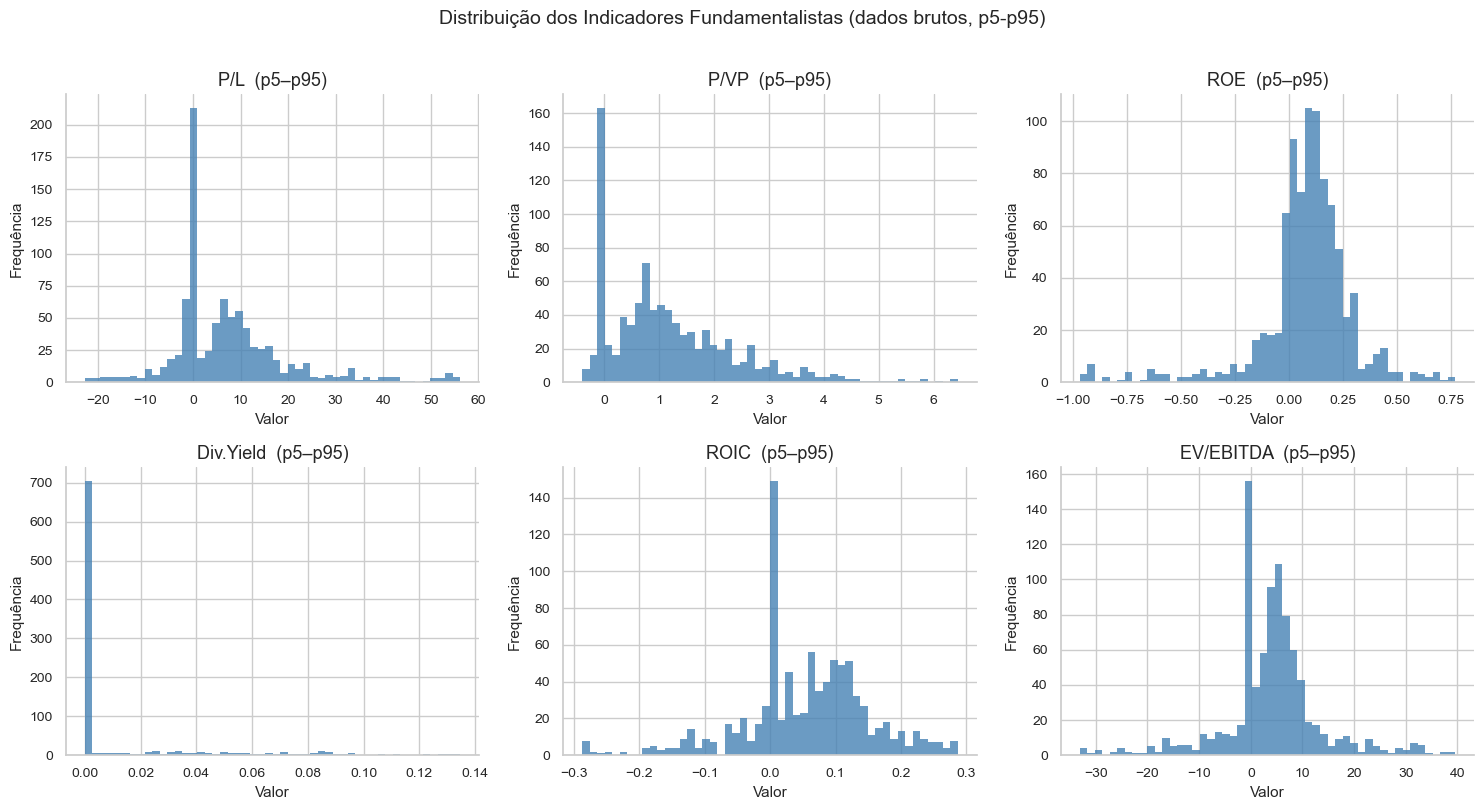

In [26]:
indicadores = ['P/L', 'P/VP', 'ROE', 'Div.Yield', 'ROIC', 'EV/EBITDA']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(indicadores):
    dados = df_raw[col].replace([float('inf'), float('-inf')], pd.NA).dropna()

    #corte nos percentis 5 e 95 apenas para visualização
    p05 = dados.quantile(0.05)
    p95 = dados.quantile(0.95)
    dados_viz = dados[(dados >= p05) & (dados <= p95)]

    axes[i].hist(dados_viz, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(f'{col}  (p5–p95)')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

fig.suptitle('Distribuição dos Indicadores Fundamentalistas (dados brutos, p5-p95)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Versão mais elaborada

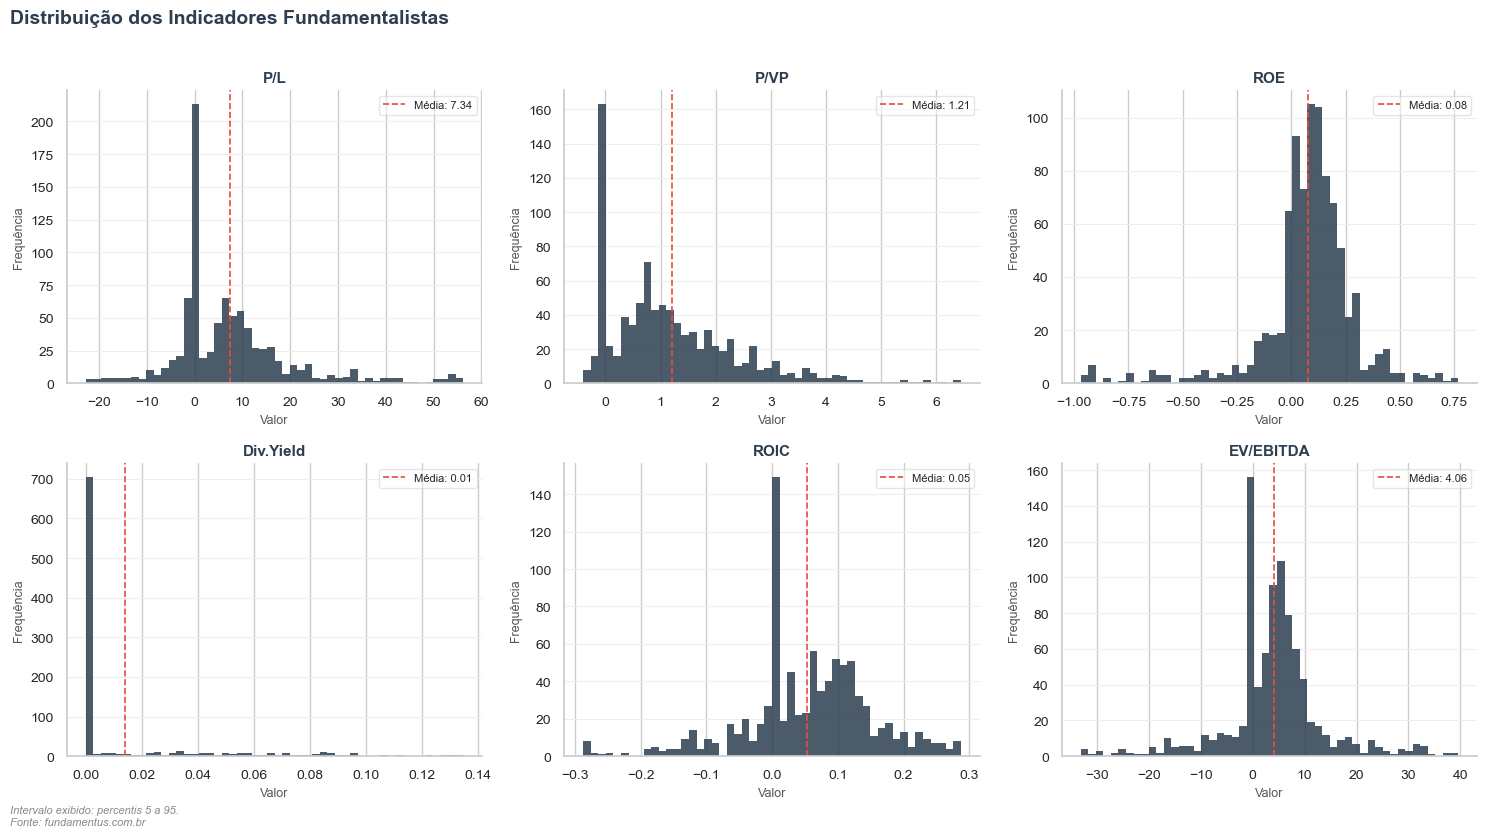

In [32]:
indicadores = ['P/L', 'P/VP', 'ROE', 'Div.Yield', 'ROIC', 'EV/EBITDA']

COR_BARRA    = '#2c3e50'
COR_MEDIA    = '#e74c3c'
COR_GRID     = '#eeeeee'
FONTE_TITULO = {'fontsize': 11, 'fontweight': 'bold', 'color': '#2c3e50'}
FONTE_EIXO   = {'fontsize': 9,  'color': '#555555'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(indicadores):
    ax = axes[i]
    dados = df_raw[col].replace([float('inf'), float('-inf')], pd.NA).dropna()

    p05 = dados.quantile(0.05)
    p95 = dados.quantile(0.95)
    dados_viz = dados[(dados >= p05) & (dados <= p95)]

    ax.hist(dados_viz, bins=50, color=COR_BARRA, edgecolor='none', alpha=0.85)

    #medias
    media = dados_viz.mean()
    ax.axvline(media, color=COR_MEDIA, linewidth=1.2, linestyle='--',
               label=f'Média: {media:.2f}')

    #grids
    ax.yaxis.grid(True, color=COR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_title(col, **FONTE_TITULO)
    ax.set_xlabel('Valor', **FONTE_EIXO)
    ax.set_ylabel('Frequência', **FONTE_EIXO)
    ax.legend(fontsize=8, framealpha=0.5)

    #remover bordas :: superior e direita
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

fig.suptitle(
    'Distribuição dos Indicadores Fundamentalistas',
    fontsize=14, fontweight='bold', color='#2c3e50',
    x=0.01, y=1.01, ha='left'
)
fig.text(
    0.01, -0.01,
    'Intervalo exibido: percentis 5 a 95.\nFonte: fundamentus.com.br',
    fontsize=8, color='#888888', style='italic'
)

plt.tight_layout()
plt.show()

## 3. Limpeza e Pré-processamento

As distribuições observadas na seção anterior confirmam o que é esperado em
dados financeiros reais: o universo bruto contém inconsistências que precisam
ser tratadas antes de qualquer análise. Empresas com patrimônio líquido
negativo, liquidez nula ou indicadores matematicamente indefinidos não
representam candidatos viáveis para o tipo de análise que proponho aqui, e
sua presença distorceria qualquer critério de seleção subsequente.

Nesta seção, aplico um conjunto de filtros de sanidade, distintos dos critérios
fundamentalistas que virão na próxima etapa. O objetivo aqui não é selecionar
boas empresas, mas remover registros que comprometem a integridade da análise.

### 3.1 Remoção de Papéis sem Liquidez

O primeiro filtro elimina papéis com liquidez média de dois meses igual a zero.
Ações sem liquidez não possuem mercado ativo, o que torna qualquer análise de
valuation irrelevante na prática: de nada adianta identificar uma ação barata
se não é possível comprá-la ou vendê-la no mercado.

In [34]:
#total inicial
df_raw.shape[0]

994

In [37]:
#liquidez 
df_raw[df_raw['Liq.2meses']>0]

Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Bruta,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Líq/ Patrim.,Cresc. Rec.5a
papel,,,,,,,,,,,,,,,,,,,,,
AALR3,3.24,-6.13,0.46,0.398,0.0000,0.163,112.89,5.72,-0.44,9.93,...,"26,83%",0.0696,-0.0570,1.01,0.0313,-0.0754,1.831410e+05,1.066930e+09,0.34,0.0234
ABCB4,24.62,6.37,0.90,0.000,0.0998,0.000,0.00,0.00,0.00,0.00,...,"0,00%",0.0000,0.0000,0.00,0.0000,0.1408,2.036980e+07,7.147590e+09,0.00,0.0566
ABEV3,16.64,16.84,2.91,2.974,0.0516,1.837,224.37,12.81,-28.81,12.01,...,"51,48%",0.2321,0.1822,1.03,0.2004,0.1728,4.662100e+08,9.012580e+10,-0.18,0.0458
ADHM3,1.56,-4.09,-1.29,770.924,0.0000,105.126,-1.43,-5.69,-1.27,-5.69,...,"100,00%",-135.4850,-188.6060,0.00,5.2170,0.3147,2.064000e+03,-1.977600e+07,0.00,0.4348
AERI3,2.34,-0.15,-0.17,0.227,0.0000,0.096,-0.80,-0.33,-0.07,-4.51,...,"-6,13%",-0.6950,-1.4732,0.69,-0.3147,1.1294,1.366390e+05,-8.364560e+08,-2.23,-0.2896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WHRL4,4.00,18.30,3.13,0.486,0.1374,0.611,-9.86,4.92,-3.91,5.01,...,"18,76%",0.0989,0.0268,0.91,0.2870,0.1712,6.513560e+04,1.918220e+09,0.06,0.0373
WIZC3,7.45,6.13,1.73,0.885,0.0844,0.493,32.57,1.77,-2.46,1.76,...,"61,24%",0.5003,0.2647,1.06,0.3487,0.2826,3.746800e+06,6.873690e+08,-0.01,0.1384
WLMM3,20.69,9.50,0.95,0.256,0.0894,0.478,1.73,5.78,5.44,7.61,...,"13,02%",0.0443,0.0269,1.89,0.1032,0.1000,1.129980e+03,7.931650e+08,0.30,0.1657


In [41]:
total_inicial = len(df_raw)

df = df_raw[df_raw['Liq.2meses'] > 0].copy()

print(f"Papéis removidos por liquidez zero : {total_inicial - len(df)}")
print(f"Papéis restantes                   : {len(df)}")

Papéis removidos por liquidez zero : 591
Papéis restantes                   : 403


### 3.2 Remoção de Papéis com Patrimônio Líquido Negativo

Patrimônio líquido negativo indica que o passivo da empresa supera seus ativos,
uma situação de insolvência técnica. Indicadores como P/VP e ROE perdem o
significado analítico nesse contexto, pois seus sinais se invertem e a
interpretação convencional deixa de ser válida.

In [42]:
antes = len(df)

df = df[df['Patrim. Líq'] > 0]

print(f"Papéis removidos por PL negativo : {antes - len(df)}")
print(f"Papéis restantes                 : {len(df)}")

Papéis removidos por PL negativo : 46
Papéis restantes                 : 357


### 3.3 Remoção de Valores Infinitos e Nulos

Alguns indicadores podem assumir valores infinitos quando o denominador da
fórmula é zero, por exemplo, um P/L calculado sobre lucro zero. Esses registros
são substituídos por nulo e removidos para garantir que os filtros numéricos
subsequentes operem sobre dados válidos.

In [43]:
antes = len(df)

df = df.replace([float('inf'), float('-inf')], pd.NA)
df = df.dropna(subset=['P/L', 'P/VP', 'ROE', 'Div.Yield', 'ROIC', 'EV/EBITDA'])

print(f"Papéis removidos por nulos/infinitos : {antes - len(df)}")
print(f"Papéis restantes                     : {len(df)}")

Papéis removidos por nulos/infinitos : 0
Papéis restantes                     : 357


O resultado zero nesta etapa não é surpreendente. Os filtros anteriores,
ao exigirem liquidez e patrimônio líquido positivos, já eliminaram os casos
que tipicamente geram valores indefinidos nos indicadores derivados.

### 3.4 Resumo da Limpeza

Consolido abaixo o impacto de cada etapa de limpeza sobre o universo de papéis,
do total bruto coletado até o conjunto saneado que será utilizado na análise.

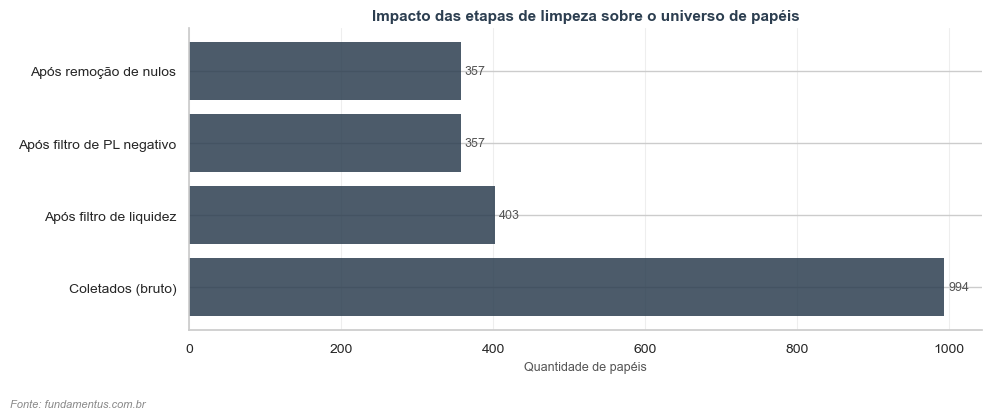

In [46]:
etapas = {
    'Coletados (bruto)'          : 994,
    'Após filtro de liquidez'    : 403,
    'Após filtro de PL negativo' : 357,
    'Após remoção de nulos'      : 357,
}

fig, ax = plt.subplots(figsize=(10, 4))

barras = ax.barh(
    list(etapas.keys()),
    list(etapas.values()),
    color=COR_BARRA, alpha=0.85, edgecolor='none'
)

for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 5, barra.get_y() + barra.get_height() / 2,
            f'{int(largura)}', va='center', fontsize=9, color='#555555')

ax.set_xlabel('Quantidade de papéis', **FONTE_EIXO)
ax.set_title('Impacto das etapas de limpeza sobre o universo de papéis',
             **FONTE_TITULO)
ax.xaxis.grid(True, color=COR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

fig.text(0.01, -0.04, 'Fonte: fundamentus.com.br',
         fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()